In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es

Default device set to: cuda


# define atlas and dirs

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [3]:
# roi (full cerebellum)
ROI_cortex = np.arange(0, 33)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'

parcelation = atlas.read_data(model_name)
ROI_mask = np.isin(parcelation, ROI_cortex).astype(int)
ROI_indices = np.arange(ROI_mask.shape[0])

# Load data

- mdtb_1 - run: Data used to make libray of tasks and to use task batteries for parcellations
- mdtb_1 - all: Data used to pick the Vs of the top parcels
- mdtb_2 - all: Data used to test parcellation predicition error

In [7]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and remove the rest row from each run


In [8]:
data_mdtb_s1_run,info_mdtb_1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run.shape)

data_mdtb_s1_all,info_mdtb_1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_all.shape)



(24, 448, 6918)
(24, 28, 6918)


# Get crossvalidated second moment matrix (GLib)

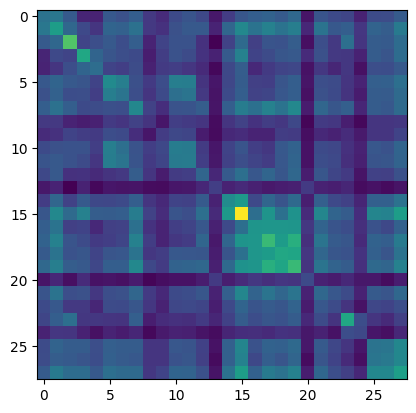

In [9]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [10]:
battery_sizes = [3,4,5,6,7,8,10,12,14,16,18,20]
parcel_sizes = [2,4,6,8,10]


In [11]:
results_df = pd.DataFrame()

for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")

        # only use top n parcels
        VLib, parcel_list = es.get_training_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI = ROI_mask, n_parcels=n_parcel)
        vtest = es.get_testing_Vs(data_mdtb_s2_all,parcellation=parcelation,ROI = ROI_mask,selected_parcels=parcel_list)

        # Generate possible battery combinations for current battery size and evaluate each battery
        D = ut.build_combinations(G_Lib, strategy='random',n_iter=1000,n_tasks=n_task,seed=1,replacement=False)
        D = D.reset_index(drop=True)
        D_ev = ev.real_evaluate_dataframe_multiregion(D, data_mdtb_s1_run,info_mdtb_1_run,VLib,data_mdtb_s2_all, vtest,ROI_indices)

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    


Processing parcel size: 2
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing battery size: 5
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing battery size: 7
Processing combination: 0
Processing battery size: 8
Processing combination: 0
Processing battery size: 10
Processing combination: 0
Processing battery size: 12
Processing combination: 0
Processing battery size: 14
Processing combination: 0
Processing battery size: 16
Processing combination: 0
Processing battery size: 18
Processing combination: 0
Processing battery size: 20
Processing combination: 0
Processing parcel size: 4
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing battery size: 5
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing battery size: 7
Processing combination: 0
Processing battery size: 8
Processing com

In [20]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cerebellum_MDTB_ses-01_ses-02_results.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
results_df = pd.read_csv(name, sep="\t")

In [21]:
results_df

,variance,variance_mc,inverse_trace,inverse_trace_mc,log_det,log_det_mc,num_eigenvalues,combination,n_unique,cos,cos_std,n_parcel,n_task
0,0.011911,0.005015,-1.412212e+03,-1.000000e+12,-17.579836,-39.934325,3,"(20, 22, 27)",3,0.790267,0.070857,2,3
1,0.011787,0.002837,-1.963707e+03,-1.000000e+12,-18.139347,-40.911344,3,"(0, 22, 26)",3,0.792880,0.074510,2,3
2,0.012723,0.003734,-2.220176e+03,-1.000000e+12,-17.980875,-40.765369,3,"(0, 14, 22)",3,0.807001,0.063211,2,3
3,0.013684,0.006179,-9.682912e+02,-1.000000e+12,-16.758438,-39.222867,3,"(10, 16, 20)",3,0.810338,0.072365,2,3
4,0.011676,0.005787,-1.176793e+03,-1.000000e+12,-17.355700,-39.434677,3,"(9, 20, 23)",3,0.800036,0.072659,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
896394,0.124801,0.059787,-5.000004e+12,-6.000000e+12,-268.517649,-288.201186,24,"(0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 1...",24,0.723053,0.078748,14,24
896395,0.123156,0.062025,-5.000000e+12,-6.000000e+12,-262.969796,-284.603748,24,"(0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13, 14, 16...",24,0.731594,0.068047,14,24
896396,0.126620,0.061230,-5.000000e+12,-6.000000e+12,-260.979936,-283.661322,24,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14,...",24,0.706647,0.085352,14,24
896397,0.134753,0.064916,-4.000000e+12,-5.000000e+12,-242.122563,-265.305979,24,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 13, 14, 15...",24,0.722697,0.076279,14,24


# Asses the different criteria

In [30]:
n_iter = 100
confidence = 0.95
metrics  = ["variance", "variance_mc","log_det_mc"]
bootstrap_results = []
battery_sizes = results_df['n_task'].unique()
parcel_sizes = results_df['n_parcel'].unique()

for i in parcel_sizes:
    print(f"Processing parcel size: {i}")
    for j in battery_sizes:
        print(f"Processing battery size: {j}")
        subset = results_df[(results_df['n_task'] == j) & (results_df['n_parcel'] == i)]
        num_samples = len(subset)
        metric_cos_values = {metric: [] for metric in metrics}
    
        for _ in range(n_iter):
            resampled = subset.sample(n=num_samples, replace=True)
            
            for metric in metrics:
                best_combination = resampled.nlargest(1, metric).sample(1)
                metric_cos_values[metric].append(best_combination['cos'])

        # Compute statistics for each metric
        for metric, cos_values in metric_cos_values.items():
            mean_cos = np.mean(cos_values)
            lower_ci, upper_ci = np.percentile(cos_values, [(1-confidence)/2 * 100, (1 + confidence)/2 * 100])
            
            bootstrap_results.append({
                'n_parcel': i,
                'n_task': j,
                'metric': metric,
                'mean_cos': mean_cos,
                'lower_ci': lower_ci,
                'upper_ci': upper_ci
            })

bootstrap_df = pd.DataFrame(bootstrap_results)


Processing parcel size: 2
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing battery size: 16
Processing battery size: 18
Processing battery size: 20
Processing battery size: 22
Processing battery size: 24
Processing parcel size: 4
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing battery size: 12
Processing battery size: 14
Processing battery size: 16
Processing battery size: 18
Processing battery size: 20
Processing battery size: 22
Processing battery size: 24
Processing parcel size: 6
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing batt

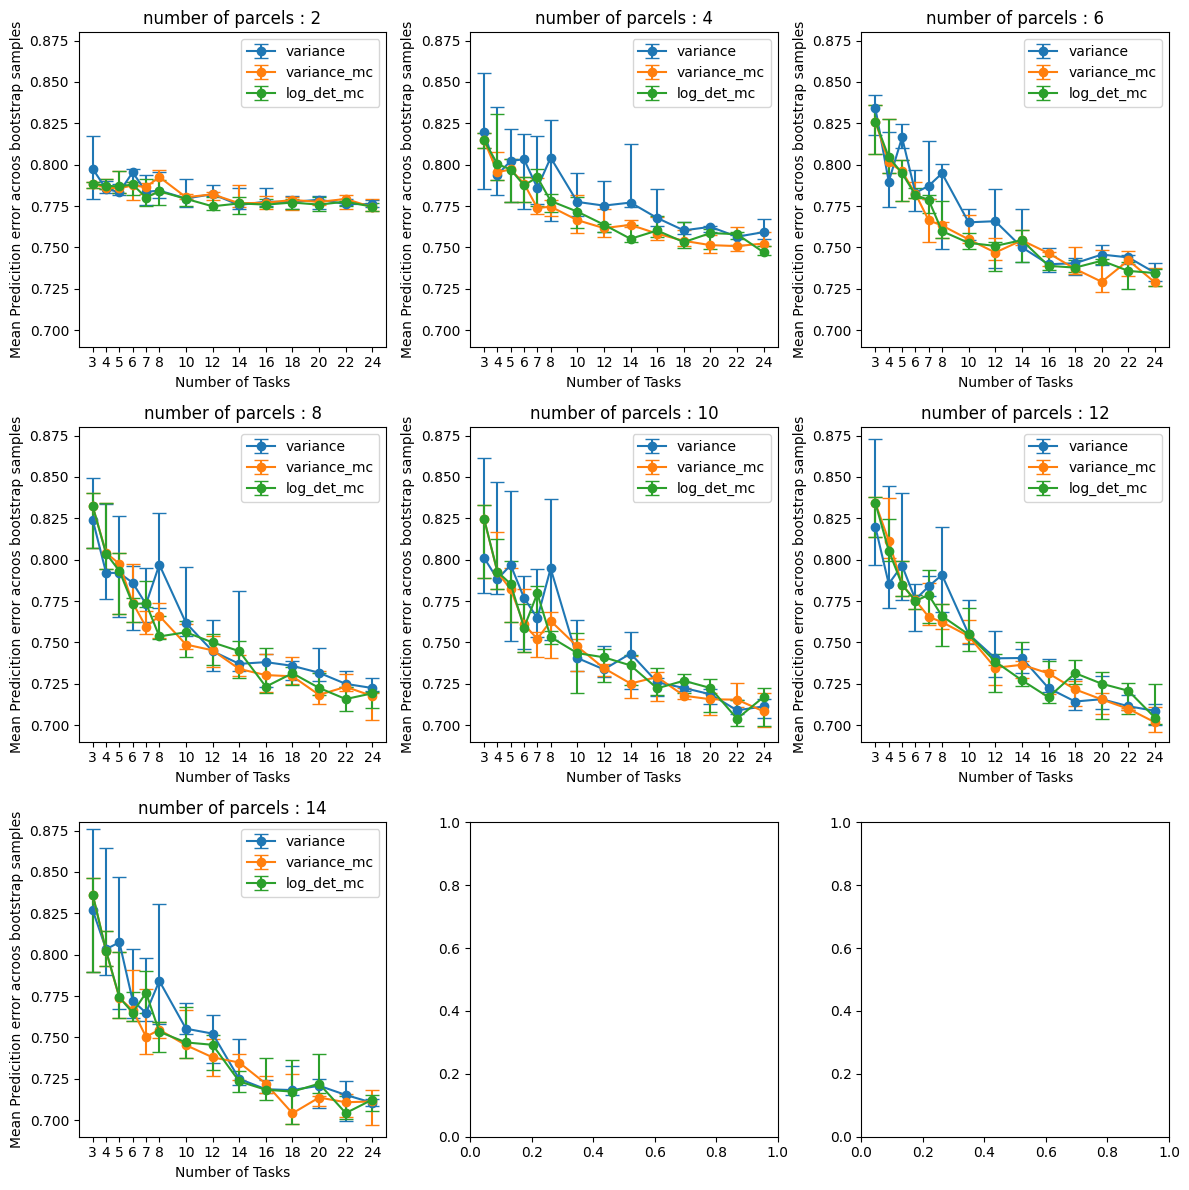

In [32]:
num_parcels = len(parcel_sizes)

# Determine grid layout (square-like)
ncols = int(np.ceil(np.sqrt(num_parcels)))  
nrows = int(np.ceil(num_parcels / ncols))  
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows), sharex=False)

axes = np.array(axes).flatten()

for ax, parcel in zip(axes, parcel_sizes):
    subset = bootstrap_df[bootstrap_df['n_parcel'] == parcel]

    for metric in metrics:
        metric_subset = subset[subset['metric'] == metric]
        ax.errorbar(
            metric_subset['n_task'], 
            metric_subset['mean_cos'], 
            yerr=[metric_subset['mean_cos'] - metric_subset['lower_ci'], 
                  metric_subset['upper_ci'] - metric_subset['mean_cos']], 
            fmt='o-', capsize=5, label=metric
        )

    ax.set_title(f"number of parcels : {parcel}")
    ax.set_xlabel("Number of Tasks")
    ax.set_ylabel("Mean Predicition error acroos bootstrap samples")
    ax.set_xticks(sorted(subset['n_task'].unique()))
    ax.legend()

    ax.set_ylim(0.69, 0.88)

plt.tight_layout()
plt.show()
